## H2O AutoML Level 2

In [1]:
!pip install -U pip
!pip install -U h2o


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 22.7 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.4/266.4 MB 27.3 MB/s  0:00:09


In [2]:
!pip install -q h2o shap lime


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
# ============================================================
# Imports
# ============================================================

import os
import shutil
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import h2o
from h2o.automl import H2OAutoML

from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss,
    log_loss,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,

)

from sklearn.model_selection import train_test_split

from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score

import shap
from lime.lime_tabular import LimeTabularExplainer

print("H2O import ok")


H2O import ok


# 0) User config

In [4]:
TRAIN_PATH = "/content/train_raw.csv"
VAL_PATH   = "/content/val_raw.csv"
TEST_PATH  = "/content/test_raw.csv"

OUT_DIR = "/content/h2o_level1_outputs"
MODEL_DIR = os.path.join(OUT_DIR, "h2o_model")
EXPLAIN_DIR = os.path.join(OUT_DIR, "explainability")
PLOT_DIR = os.path.join(OUT_DIR, "thesis_plots")

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(EXPLAIN_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

TARGET = "Default"
SEED = 42

# like AutoGluon time_limit=1800
MAX_RUNTIME_SECS = 600

# If None, H2O uses the time limit.
MAX_MODELS = None

# Explainability settings
EXPLAIN_N_ROWS = 1000
LOCAL_EXPLAIN_ROW_INDEXES = [0, 1, 2]

# For PD calculation
CONSERVATISM_UPLIFT = 0.30

# moc_a
MOC_A_UPLIFT = 0.05

# floor
APPLY_PD_FLOOR = True
PD_FLOOR = 0.0005

N_BOOT_TEST = 5
N_BOOT_TRAIN = 3
BOOTSTRAP_TIME_LIMIT = 60
BOOTSTRAP_MAX_MODELS = 3      # Unlike AutoGluon, H2O AutoML provides an explicit model-based stopping criterion via the max_models parameter in addition to time-based limits



# 1) Helper functions

In [5]:
def logit(p):
    p = np.clip(np.asarray(p, dtype=float), 1e-12, 1 - 1e-12)
    return np.log(p / (1 - p))


def inv_logit(z):
    return 1 / (1 + np.exp(-np.asarray(z, dtype=float)))


def calibrate_to_target_lradr(pd_values, target_mean, tol=1e-12):
    """
    Apply one global logit shift so that the average PD equals the proxy LRADR.
    """
    if not (0 < target_mean < 1):
        raise ValueError("target_mean must be between 0 and 1")

    base_logit = logit(pd_values)

    lower = -20.0
    upper = 20.0

    for _ in range(250):
        alpha = (lower + upper) / 2
        calibrated_pd = inv_logit(base_logit + alpha)

        if abs(calibrated_pd.mean() - target_mean) < tol:
            break

        if calibrated_pd.mean() < target_mean:
            lower = alpha
        else:
            upper = alpha

    return inv_logit(base_logit + alpha), float(alpha)


def apply_final_pd_adjustments(pd_be, moc_a=None, moc_c=None, pd_floor=PD_FLOOR):
    pd_final = np.asarray(pd_be, dtype=float)

    if moc_a is not None:
        pd_final = pd_final + np.asarray(moc_a, dtype=float)

    if moc_c is not None:
        pd_final = pd_final + np.asarray(moc_c, dtype=float)

    if APPLY_PD_FLOOR:
        pd_final = np.maximum(pd_final, pd_floor)

    return np.clip(pd_final, 0, 1)


def make_h2o_frame(df, target):
    frame = h2o.H2OFrame(df)
    frame[target] = frame[target].asfactor()
    return frame


def train_h2o_automl_bootstrap(
    train_h2o,
    val_h2o,
    features,
    target,
    max_runtime_secs,
    max_models,
    seed,
):
    aml_boot = H2OAutoML(
        max_runtime_secs=max_runtime_secs,
        max_models=BOOTSTRAP_MAX_MODELS,
        seed=seed,
        sort_metric="AUCPR",
        stopping_metric="AUCPR",
        balance_classes=False,
        verbosity="warn",
    )

    aml_boot.train(
        x=features,
        y=target,
        training_frame=train_h2o,
        validation_frame=val_h2o,
        leaderboard_frame=val_h2o,
        weights_column="row_weight"
    )
    return aml_boot


def bootstrap_moc_c_h2o(
    train_data,
    eval_data,
    calibration_alpha,
    features,
    target,
    n_boot=5,
    alpha_q=0.95,
    random_state=42,
):
    rng = np.random.RandomState(random_state)
    all_pd_predictions = []

    train_data = train_data.reset_index(drop=True)
    eval_data = eval_data.reset_index(drop=True)

    eval_h2o = make_h2o_frame(eval_data, target)

    # make sure the weight colum is not in the features
    features_clean = [f for f in features if f != "row_weight"]

    for b in range(n_boot):
        sample_idx = rng.randint(0, len(train_data), len(train_data))
        train_boot = train_data.iloc[sample_idx].reset_index(drop=True)

        # calculating the row_weight after Resampling for the dev/val-Splits
        train_boot["row_weight"] = calculate_inverse_weights(train_boot, target)

        train_boot_dev, train_boot_val = train_test_split(
            train_boot,
            test_size=0.20,
            random_state=random_state + b,
            stratify=train_boot[target],
        )

        # dataframes in H2O-frames
        train_boot_h2o = h2o.H2OFrame(train_boot_dev)
        val_boot_h2o   = h2o.H2OFrame(train_boot_val)

        # declare target as factor/categorie
        train_boot_h2o[target] = train_boot_h2o[target].asfactor()
        val_boot_h2o[target]   = val_boot_h2o[target].asfactor()

        # call normal H2O configs
        aml_boot = train_h2o_automl_bootstrap(
            train_h2o=train_boot_h2o,
            val_h2o=val_boot_h2o,
            features=features_clean,
            target=target,
            max_runtime_secs=BOOTSTRAP_TIME_LIMIT,
            max_models=BOOTSTRAP_MAX_MODELS,
            seed=random_state + b,
        )

        # to avoid break up if  train_h2o_automl_bootstrap gives back None/ no model was finished
        if aml_boot is None or getattr(aml_boot, "leader", None) is None:
            from h2o.estimators import H2OGeneralizedLinearEstimator
            print(f"  [Warning] Bootstrap run {b} timed out before a model was built. Training fast fallback GLM...")

            # fallback: standard GLM as it takes a few seconds
            leader_model = H2OGeneralizedLinearEstimator(family="binomial", seed=random_state + b)
            leader_model.train(
                x=features_clean,
                y=target,
                training_frame=train_boot_h2o,
                weights_column="row_weight"
            )
        else:
            leader_model = aml_boot.leader

        # PD predictions with "new" model
        pd_raw = get_positive_class_proba_h2o(leader_model, eval_h2o)
        pd_calibrated = inv_logit(logit(pd_raw) + calibration_alpha)

        all_pd_predictions.append(pd_calibrated)

        # secure deleting of all inbetween-models in the H2O cluster
        try:
            if aml_boot is not None and getattr(aml_boot, "leaderboard", None) is not None:
                model_ids = aml_boot.leaderboard.as_data_frame()["model_id"].tolist()
                for model_id in model_ids:
                    try:
                        h2o.remove(model_id)
                    except Exception:
                        pass

            # if the fallback model was created, explicitly deleting this one
            if aml_boot is None or getattr(aml_boot, "leader", None) is None:
                h2o.remove(leader_model.model_id)

            h2o.remove(train_boot_h2o)
            h2o.remove(val_boot_h2o)
        except Exception:
            pass

    pred_matrix = np.vstack(all_pd_predictions)

    pd_mean = pred_matrix.mean(axis=0)
    pd_quantile = np.quantile(pred_matrix, alpha_q, axis=0)

    moc_c = np.maximum(pd_quantile - pd_mean, 0.0)

    try:
        h2o.remove(eval_h2o)
    except Exception:
        pass

    return pd_mean, moc_c, pred_matrix


def get_positive_class_proba_h2o(model, frame):
    """Return positive class probabilities from an H2O binary classifier."""
    pred = model.predict(frame).as_data_frame()

    # H2O binary predictions usually contain: predict, p0, p1
    if "p1" in pred.columns:
        return pred["p1"].astype(float).to_numpy()

    # Robust fallback: use last probability-like column
    prob_cols = [c for c in pred.columns if c.startswith("p")]
    if len(prob_cols) == 0:
        raise ValueError(f"No probability columns found in H2O predictions: {pred.columns.tolist()}")

    return pred[prob_cols[-1]].astype(float).to_numpy()

# Calculation of Row Weights (Inverse Class Frequency) so it is comparable to AutoGluon (--> in H20 there is no in-bulid hyperparameter)
def calculate_inverse_weights(df, target_col):
    total_samples = len(df)
    n_classes = df[target_col].nunique()

    # Count the frequency of each class
    class_counts = df[target_col].value_counts()

    # formular for balanced weights: total_samples / (n_classes * class_count)
    weights_map = {
        cls: total_samples / (n_classes * count)
        for cls, count in class_counts.items()
    }

    # Map weights to the rows
    return df[target_col].map(weights_map)




# 2) Load fixed splits

In [6]:
train = pd.read_csv(TRAIN_PATH)
val   = pd.read_csv(VAL_PATH)
test  = pd.read_csv(TEST_PATH)

print("Train shape:", train.shape)
print("Val shape:", val.shape)
print("Test shape:", test.shape)

if TARGET not in train.columns:
    raise ValueError(f"Target column '{TARGET}' not found in train data.")

if TARGET not in val.columns:
    raise ValueError(f"Target column '{TARGET}' not found in validation data.")

if TARGET not in test.columns:
    raise ValueError(f"Target column '{TARGET}' not found in test data.")

# Ensures binary target is represented consistently as 0/1 integers in pandas.
for df_name, df in [("train", train), ("val", val), ("test", test)]:
    df[TARGET] = df[TARGET].astype(int)
    unique_values = sorted(df[TARGET].dropna().unique())
    if not set(unique_values).issubset({0, 1}):
        raise ValueError(f"{df_name}: Target must be binary 0/1. Found: {unique_values}")

### for the row weight ##
train = train.copy()
val = val.copy()
test = test.copy()

train["row_weight"] = calculate_inverse_weights(train, TARGET)
val["row_weight"] = calculate_inverse_weights(val, TARGET)
test["row_weight"] = 1.0    # Prevents the "missing column" warning in the test set


Train shape: (153207, 17)
Val shape: (51070, 17)
Test shape: (51070, 17)


# 3) Start H2O and convert data

In [7]:
# Start H2O cluster


h2o.init(max_mem_size="10G")
h2o.no_progress()

# Convert pandas DataFrames to H2OFrames
train_h2o = h2o.H2OFrame(train)
val_h2o   = h2o.H2OFrame(val)
test_h2o  = h2o.H2OFrame(test)

# H2O needs the binary target as factor/categorical for classification
train_h2o[TARGET] = train_h2o[TARGET].asfactor()
val_h2o[TARGET]   = val_h2o[TARGET].asfactor()
test_h2o[TARGET]  = test_h2o[TARGET].asfactor()

#  'row_weight' is not a feature --> risk of Data Leakage (as it learns the weights for prediction)
FEATURES = [c for c in train.columns if c not in [TARGET, "row_weight"]]

print("Number of features:", len(FEATURES))
print("Features:", FEATURES)




Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.19" 2026-04-21; OpenJDK Runtime Environment (build 17.0.19+10-1-22.04.2-Ubuntu); OpenJDK 64-Bit Server VM (build 17.0.19+10-1-22.04.2-Ubuntu, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmp37xz6t6j
  JVM stdout: /tmp/tmp37xz6t6j/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmp37xz6t6j/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,07 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.11
H2O_cluster_version_age:,18 days
H2O_cluster_name:,H2O_from_python_unknownUser_cz9oaj
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,10 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Number of features: 16
Features: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


# 4) H2O AutoML

In [8]:
aml_kwargs = {
    "max_runtime_secs": MAX_RUNTIME_SECS,
    "seed": SEED,
    "sort_metric": "AUCPR",
    "stopping_metric": "AUCPR",
    "balance_classes": False,      # False as weight_row is used
    "verbosity": "info",
}

if MAX_MODELS is not None:
    aml_kwargs["max_models"] = MAX_MODELS

aml = H2OAutoML(**aml_kwargs)

aml.train(
    x=FEATURES,
    y=TARGET,
    training_frame=train_h2o,
    validation_frame=val_h2o,
    leaderboard_frame=val_h2o,
    weights_column="row_weight"   # Forces H2O to use mathematical loss weighting
)

leader = aml.leader

print("Best H2O model id:")
print(leader.model_id)

# Save H2O leader model
saved_model_path = h2o.save_model(
    model=leader,
    path=MODEL_DIR,
    force=True,
)

print("Saved H2O leader model to:", saved_model_path)


15:48:21.354: Project: AutoML_1_20260609_154821
15:48:21.356: 5-fold cross-validation will be used.
15:48:21.357: User specified a validation frame with cross-validation still enabled. Please note that the models will still be validated using cross-validation only, the validation frame will be used to provide purely informative validation metrics on the trained models.
15:48:21.365: Setting stopping tolerance adaptively based on the training frame: 0.0025548222848548437
15:48:21.366: Build control seed: 42
15:48:21.366: training frame: Frame key: AutoML_1_20260609_154821_training_py_1_sid_a032    cols: 18    rows: 153207  chunks: 5    size: 3641122  checksum: -448748897555378768
15:48:21.369: validation frame: Frame key: py_2_sid_a032    cols: 18    rows: 51070  chunks: 2    size: 1216558  checksum: 3791734936372173160
15:48:21.370: leaderboard frame: Frame key: py_2_sid_a032    cols: 18    rows: 51070  chunks: 2    size: 1216558  checksum: 3791734936372173160
15:48:21.370: blending f

# 5) Evaluation on unseen test set

In [9]:
test_results = leader.model_performance(test_h2o)

print(test_results)

ModelMetricsBinomialGLM: glm
** Reported on test data. **

MSE: 0.20499375201378278
RMSE: 0.4527623571077688
LogLoss: 0.5947121336531168
AUC: 0.753275755214296
AUCPR: 0.3102650672194613
Gini: 0.506551510428592
Null degrees of freedom: 51069
Residual degrees of freedom: 51038
Null deviance: 70798.05302234995
Residual deviance: 60743.897331329346
AIC: 60807.897331329346

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.6201824203546811
       0      1      Error    Rate
-----  -----  -----  -------  -----------------
0      37494  7645   0.1694   (7645.0/45139.0)
1      2870   3061   0.4839   (2870.0/5931.0)
Total  40364  10706  0.2059   (10515.0/51070.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.620182     0.367975  114
max f2                       0.461609     0.492322  193
max f0point5                 0.740498    

# 6) Leaderboard

In [10]:
leaderboard = aml.leaderboard.as_data_frame()

print(leaderboard)

leaderboard.to_csv(
    os.path.join(OUT_DIR, "leaderboard_validation.csv"),
    index=False,
)


                                             model_id     aucpr       auc  \
0                      GLM_1_AutoML_1_20260609_154821  0.737321  0.745407   
1                      GBM_2_AutoML_1_20260609_154821  0.736914  0.741041   
2                      GBM_1_AutoML_1_20260609_154821  0.735455  0.741105   
3                      GBM_3_AutoML_1_20260609_154821  0.735355  0.741126   
4                      GBM_4_AutoML_1_20260609_154821  0.729025  0.734287   
5                  XGBoost_2_AutoML_1_20260609_154821  0.715832  0.719655   
6                  XGBoost_1_AutoML_1_20260609_154821  0.698199  0.707729   
7                      DRF_1_AutoML_1_20260609_154821  0.622396  0.614902   
8   StackedEnsemble_BestOfFamily_1_AutoML_1_202606...  0.312167  0.749775   
9   StackedEnsemble_BestOfFamily_2_AutoML_1_202606...  0.189464  0.614196   
10  StackedEnsemble_AllModels_1_AutoML_1_20260609_...  0.189463  0.614196   

     logloss  mean_per_class_error      rmse       mse  
0   0.595001      

/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


# 7) Calibration

In [11]:
# ============================================================
# raw PD -> BE calibration -> MoC_A -> MoC_C -> PD floor -> final PD
# ============================================================

train_final = pd.concat([train, val], axis=0).reset_index(drop=True)
test_final = test.copy().reset_index(drop=True)

train_final_h2o = make_h2o_frame(train_final, TARGET)
test_final_h2o = make_h2o_frame(test_final, TARGET)

y_train_final = train_final[TARGET].astype(int).to_numpy()
y_test_final = test_final[TARGET].astype(int).to_numpy()

# Raw H2O PDs
pd_train_raw = get_positive_class_proba_h2o(leader, train_final_h2o)
pd_test_raw = get_positive_class_proba_h2o(leader, test_final_h2o)

# Best-estimate calibration to proxy LRADR
observed_train_dr = float(np.mean(y_train_final))

proxy_lradr = observed_train_dr * (1 + CONSERVATISM_UPLIFT)
proxy_lradr = min(max(proxy_lradr, 1e-6), 1 - 1e-6)

pd_train_be, alpha_shift = calibrate_to_target_lradr(
    pd_train_raw,
    proxy_lradr
)

pd_test_be = inv_logit(logit(pd_test_raw) + alpha_shift)

# MoC_C via bootstrap
pd_train_boot_mean, moc_c_train, pred_matrix_train = bootstrap_moc_c_h2o(
    train_data=train_final,
    eval_data=train_final,
    calibration_alpha=alpha_shift,
    features=FEATURES,
    target=TARGET,
    n_boot=N_BOOT_TRAIN,
    alpha_q=0.95,
    random_state=SEED,
)

pd_test_boot_mean, moc_c_test, pred_matrix_test = bootstrap_moc_c_h2o(
    train_data=train_final,
    eval_data=test_final,
    calibration_alpha=alpha_shift,
    features=FEATURES,
    target=TARGET,
    n_boot=N_BOOT_TEST,
    alpha_q=0.95,
    random_state=SEED + 1,
)

# MoC_A
moc_a_train = pd_train_be * MOC_A_UPLIFT
moc_a_test = pd_test_be * MOC_A_UPLIFT

# Final PDs
pd_train_final = apply_final_pd_adjustments(
    pd_be=pd_train_be,
    moc_a=moc_a_train,
    moc_c=moc_c_train,
    pd_floor=PD_FLOOR,
)

pd_test_final = apply_final_pd_adjustments(
    pd_be=pd_test_be,
    moc_a=moc_a_test,
    moc_c=moc_c_test,
    pd_floor=PD_FLOOR,
)

print("Observed train DR:", observed_train_dr)
print("Proxy LRADR:", proxy_lradr)
print("Alpha shift:", alpha_shift)
print("Mean MoC_A test:", np.mean(moc_a_test))
print("Mean MoC_C test:", np.mean(moc_c_test))
print("Mean final PD test:", np.mean(pd_test_final))



/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow a

Observed train DR: 0.11612663197521013
Proxy LRADR: 0.15096462156777318
Alpha shift: -1.6886564142805582
Mean MoC_A test: 0.007605389647353276
Mean MoC_C test: 0.0745331203019609
Mean final PD test: 0.23421193132275245


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


# 8) H2O built-in explainability / transparency

Generating H2O explainability report on 1000 rows...


# Leaderboard

> Leaderboard shows models with their metrics. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo
StackedEnsemble_BestOfFamily_1_AutoML_1_20260609_154821,0.743791,0.308774,0.324999,0.321388,0.298276,0.0889684,70947,0.033929,StackedEnsemble
GLM_1_AutoML_1_20260609_154821,0.742303,0.607479,0.317721,0.306628,0.458853,0.210546,8652,0.007702,GLM
GBM_1_AutoML_1_20260609_154821,0.739493,0.532136,0.308293,0.326979,0.420026,0.176422,14515,0.02179,GBM
GBM_2_AutoML_1_20260609_154821,0.73436,0.60836,0.310336,0.30522,0.457558,0.20936,4032,0.016541,GBM
GBM_4_AutoML_1_20260609_154821,0.731851,0.584892,0.293441,0.322313,0.445135,0.198145,3857,0.011776,GBM
GBM_3_AutoML_1_20260609_154821,0.726693,0.614414,0.329373,0.331564,0.460488,0.21205,3245,0.014344,GBM
XGBoost_2_AutoML_1_20260609_154821,0.703618,0.573887,0.265425,0.352357,0.441443,0.194872,5334,0.010993,XGBoost
XGBoost_1_AutoML_1_20260609_154821,0.674625,0.497364,0.263024,0.366795,0.404502,0.163622,26906,0.026414,XGBoost
DRF_1_AutoML_1_20260609_154821,0.60847,2.07211,0.192429,0.401665,0.350731,0.123012,2728,0.010066,DRF
StackedEnsemble_AllModels_1_AutoML_1_20260609_154821,0.60847,0.346047,0.192429,0.401665,0.313834,0.0984916,22418,0.016144,StackedEnsemble


# Variable Importance

> The variable importance plot shows the relative importance of the most important variables in the model.

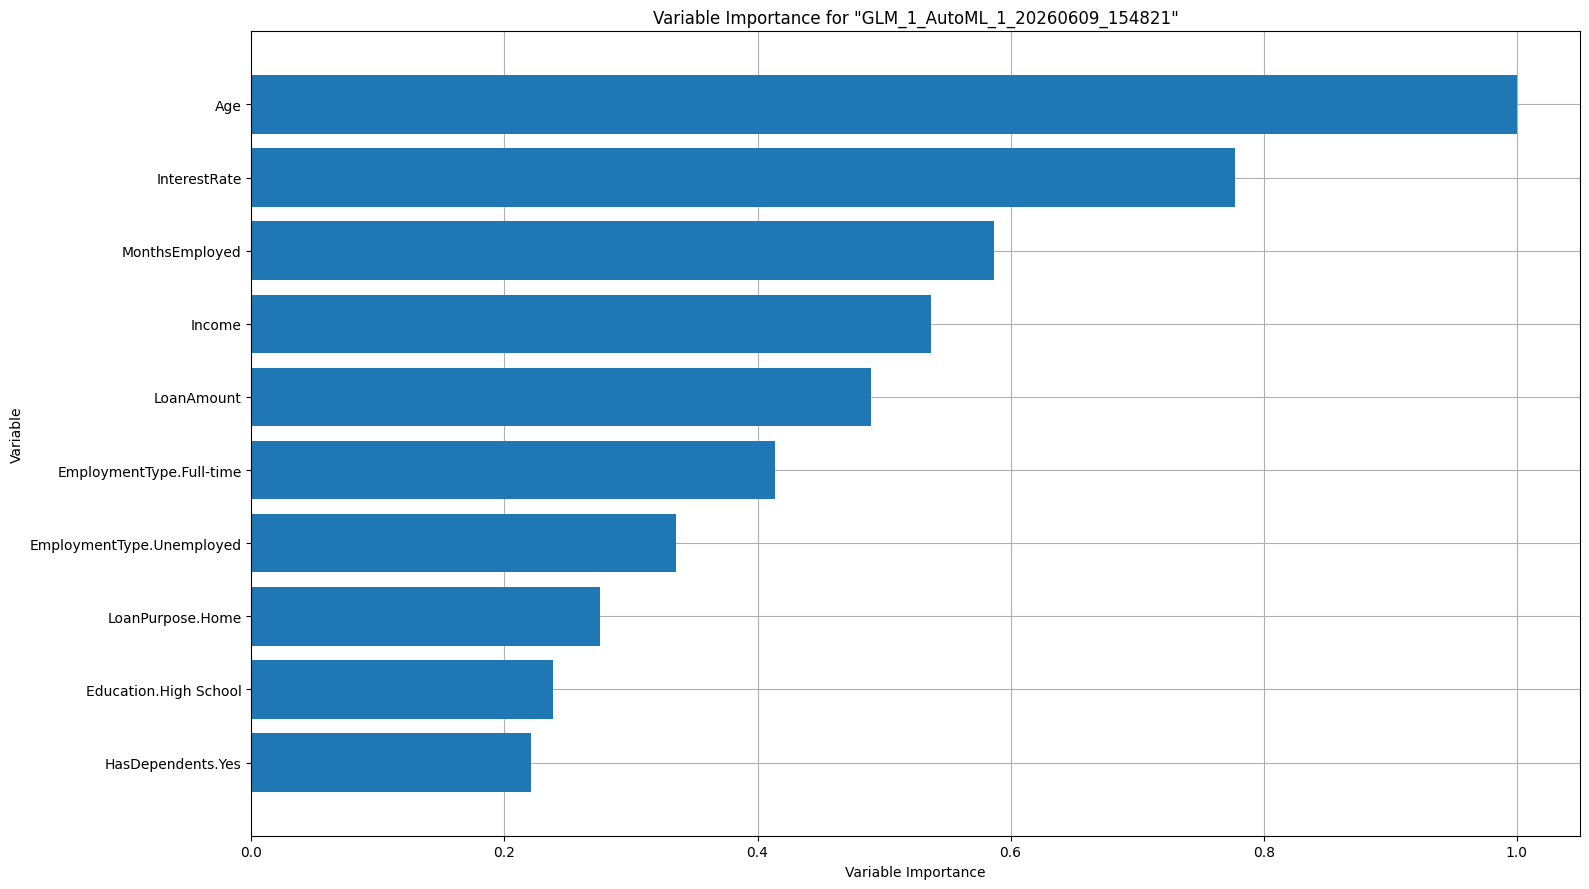

# Variable Importance Heatmap

> Variable importance heatmap shows variable importance across multiple models. Some models in H2O return variable importance for one-hot (binary indicator) encoded versions of categorical columns (e.g. Deep Learning, XGBoost). In order for the variable importance of categorical columns to be compared across all model types we compute a summarization of the the variable importance across all one-hot encoded features and return a single variable importance for the original categorical feature. By default, the models and variables are ordered by their similarity.

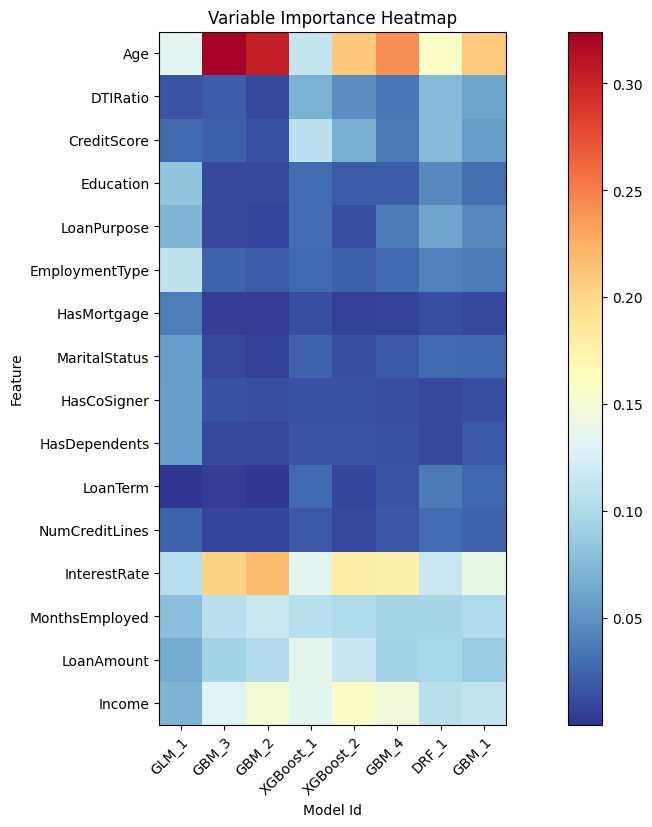

# Model Correlation

> This plot shows the correlation between the predictions of the models. For classification, frequency of identical predictions is used. By default, models are ordered by their similarity (as computed by hierarchical clustering). Interpretable models, such as GAM, GLM, and RuleFit are highlighted using red colored text.

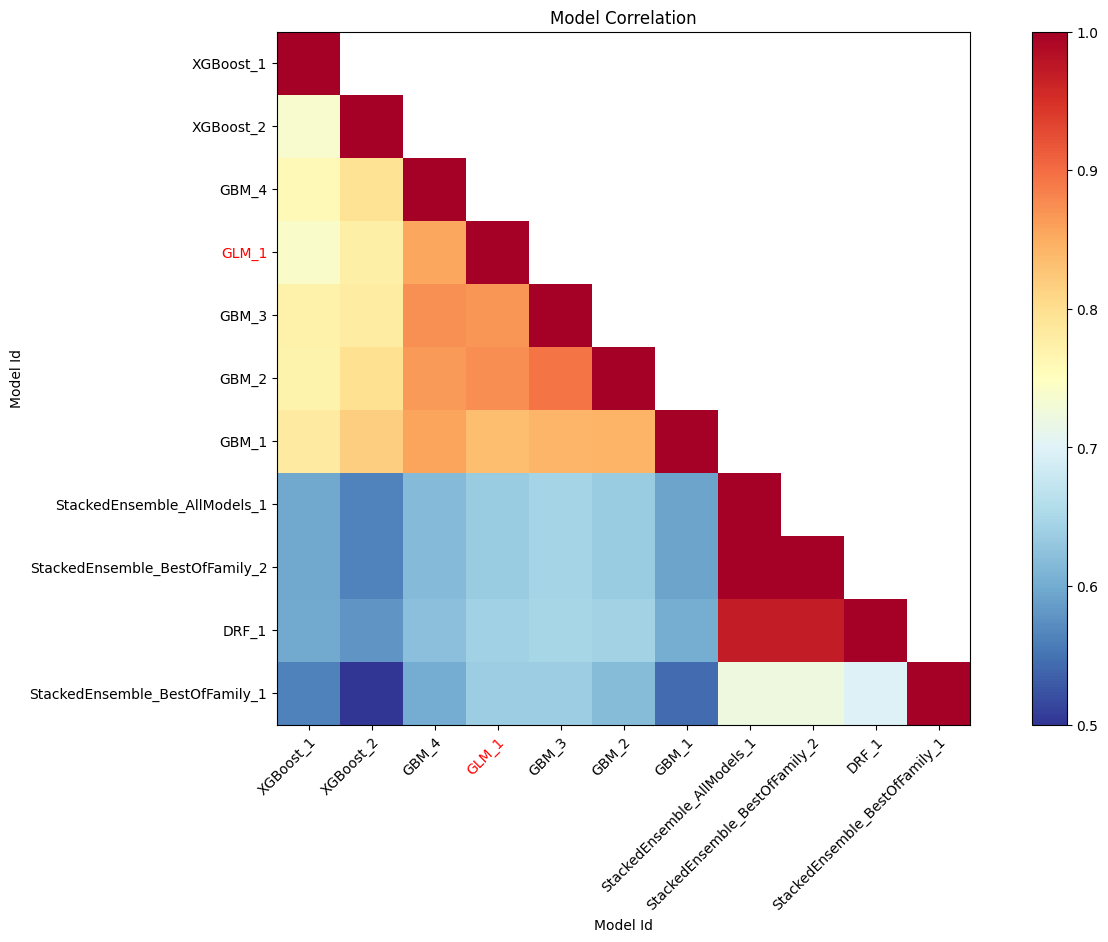

# SHAP Summary

> SHAP summary plot shows the contribution of the features for each instance (row of data). The sum of the feature contributions and the bias term is equal to the raw prediction of the model, i.e., prediction before applying inverse link function.

h2o.explain could not render all requested explanations.
This can happen for Stacked Ensembles or unsupported model types.
Reason: Server error java.lang.IllegalArgumentException:
  Error: Incorrect number of arguments; 'cols_py' expects 2 but was passed 3
  Request: POST /99/Rapids
    data: {'ast': "(tmp= py_205_sid_a032 (levels (tmp= py_204_sid_a032 (as.factor (cols_py py_203_sid_a032 np.str_('Education'))))))", 'session_id': '_sid_a032'}



In [12]:
explain_n = min(EXPLAIN_N_ROWS, test_h2o.nrow)
explain_frame = test_h2o[:explain_n, :]

print(f"Generating H2O explainability report on {explain_n} rows...")

try:
    explanations = h2o.explain(
        aml,
        explain_frame,
        render=True,
        include_explanations=[
            "leaderboard",              # Shows the model overview
            "varimp",                   # Global Feature Importance
            "varimp_heatmap",           # Shows feature importance across all models
            "model_correlation_heatmap",# Shows how strongly the models correlate
            "shap_summary",             # Global SHAP beeswarm plot --> inbuild only TreeSHAP! --> only works for GBM, Random Forest (DRF) or XGBoost
            "residual_analysis",        # Shows the distribution of prediction errors
        ],
    )
except Exception as e:
    print("h2o.explain could not render all requested explanations.")
    print("This can happen for Stacked Ensembles or unsupported model types.")
    print("Reason:", e)

# small note so the generated artefacts folder documents this step
with open(os.path.join(EXPLAIN_DIR, "h2o_explain_report_note.txt"), "w") as f:
    f.write(
        "h2o.explain was called on the AutoML object. "
        "Rendered plots appear in the notebook output. "
        "Additional exported artefacts are saved as CSV/PNG in this folder.\n"
    )


# 8.1 Partial dependence plots for top features

Generating PDPs for: ['Age', 'InterestRate', 'MonthsEmployed', 'Income', 'LoanAmount']


/tmp/ipykernel_3903/3381079320.py:11: H2ODeprecationWarning: ``data`` param of ``ModelBase.partial_plot`` is deprecated, please use ``frame`` instead.
  leader.partial_plot(


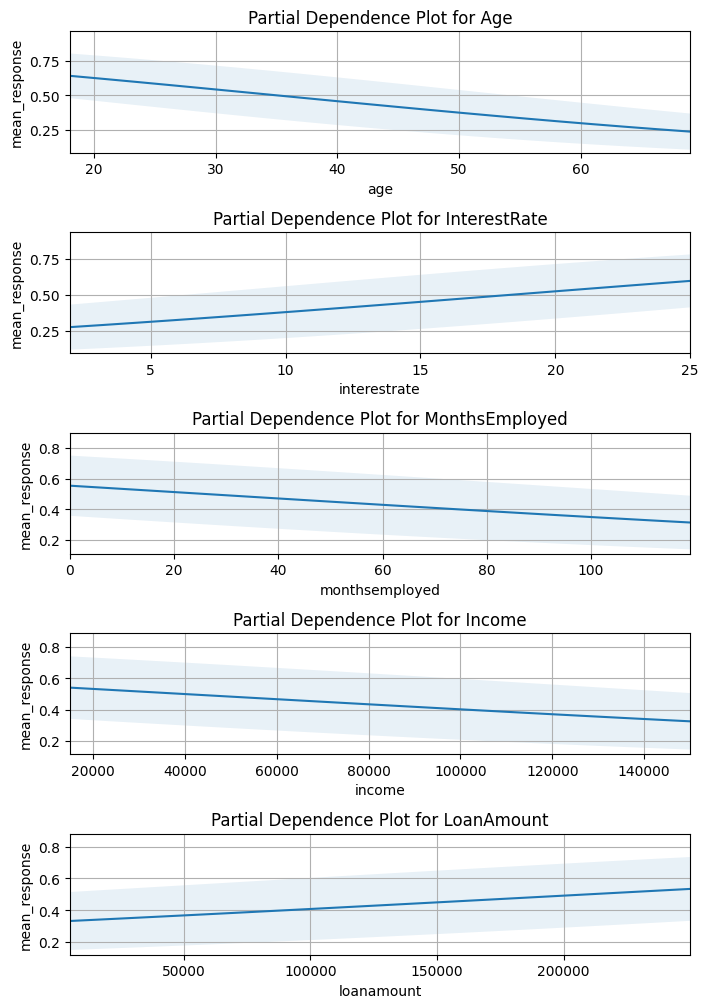

In [13]:

try:

    varimp = leader.varimp()

    if varimp is not None:

        top_features = [row[0] for row in varimp[:5]]

        print("Generating PDPs for:", top_features)

        leader.partial_plot(
            data=test_h2o,
            cols=top_features
        )

    else:
        print(
            "Partial dependence plots were skipped because "
            "the leader model does not provide variable importance."
        )

except Exception as e:

    print("Partial dependence plots could not be generated.")
    print("Reason:", e)

# 8.2) Local row-level explanations

In [14]:

#filter rows
local_rows = [i for i in LOCAL_EXPLAIN_ROW_INDEXES if i < test_h2o.nrow]

# export for documentation
pd.DataFrame({"row_index": local_rows}).to_csv(
    os.path.join(EXPLAIN_DIR, "local_explanation_rows.csv"),
    index=False,
)

# one loop
for row_idx in local_rows:
    print("Local explanation for test row:", row_idx)
    try:
        _ = h2o.explain_row(
            aml,
            test_h2o,
            row_index=row_idx,

        )
    except Exception as e:
        print(f"h2o.explain_row failed for row {row_idx}:", e)


Local explanation for test row: 0


# Leaderboard

> Leaderboard shows models with their metrics and their predictions for a given row. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo,predict,p0,p1
StackedEnsemble_BestOfFamily_1_AutoML_1_20260609_154821,0.756304,0.312456,0.320847,0.334025,0.302106,0.0912682,70947,0.018389,StackedEnsemble,0,0.97206,0.0279398
GLM_1_AutoML_1_20260609_154821,0.753276,0.594712,0.310265,0.326632,0.452762,0.204994,8652,0.00163,GLM,0,0.814584,0.185416
GBM_3_AutoML_1_20260609_154821,0.74809,0.606581,0.312859,0.337689,0.456317,0.208225,3245,0.004495,GBM,0,0.679133,0.320867
GBM_2_AutoML_1_20260609_154821,0.747184,0.603696,0.319848,0.336721,0.455116,0.207131,4032,0.005525,GBM,0,0.628733,0.371267
GBM_1_AutoML_1_20260609_154821,0.746213,0.524453,0.314052,0.336529,0.416638,0.173587,14515,0.014323,GBM,0,0.823574,0.176426
GBM_4_AutoML_1_20260609_154821,0.738162,0.582313,0.302718,0.346047,0.44378,0.196941,3857,0.005592,GBM,0,0.786743,0.213257
XGBoost_2_AutoML_1_20260609_154821,0.730819,0.564621,0.291362,0.339927,0.436636,0.190651,5334,0.003257,XGBoost,0,0.744026,0.255974
XGBoost_1_AutoML_1_20260609_154821,0.710471,0.480863,0.26126,0.36175,0.39727,0.157824,26906,0.006038,XGBoost,0,0.911133,0.0888671
DRF_1_AutoML_1_20260609_154821,0.618112,2.04613,0.190928,0.404648,0.356814,0.127316,2728,0.007205,DRF,0,1,0
StackedEnsemble_AllModels_1_AutoML_1_20260609_154821,0.616562,0.35322,0.19057,0.404648,0.318457,0.101415,22418,0.004245,StackedEnsemble,0,0.901992,0.0980079


# SHAP Explanation

...

> Leaderboard shows models with their metrics and their predictions for a given row. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo,predict,p0,p1
StackedEnsemble_BestOfFamily_1_AutoML_1_20260609_154821,0.756304,0.312456,0.320847,0.334025,0.302106,0.0912682,70947,0.018389,StackedEnsemble,0,0.917342,0.0826577
GLM_1_AutoML_1_20260609_154821,0.753276,0.594712,0.310265,0.326632,0.452762,0.204994,8652,0.00163,GLM,1,0.623449,0.376551
GBM_3_AutoML_1_20260609_154821,0.74809,0.606581,0.312859,0.337689,0.456317,0.208225,3245,0.004495,GBM,0,0.606057,0.393943
GBM_2_AutoML_1_20260609_154821,0.747184,0.603696,0.319848,0.336721,0.455116,0.207131,4032,0.005525,GBM,1,0.548264,0.451736
GBM_1_AutoML_1_20260609_154821,0.746213,0.524453,0.314052,0.336529,0.416638,0.173587,14515,0.014323,GBM,1,0.59213,0.40787
GBM_4_AutoML_1_20260609_154821,0.738162,0.582313,0.302718,0.346047,0.44378,0.196941,3857,0.005592,GBM,0,0.63636,0.36364
XGBoost_2_AutoML_1_20260609_154821,0.730819,0.564621,0.291362,0.339927,0.436636,0.190651,5334,0.003257,XGBoost,1,0.655123,0.344877
XGBoost_1_AutoML_1_20260609_154821,0.710471,0.480863,0.26126,0.36175,0.39727,0.157824,26906,0.006038,XGBoost,1,0.754931,0.245069
DRF_1_AutoML_1_20260609_154821,0.618112,2.04613,0.190928,0.404648,0.356814,0.127316,2728,0.007205,DRF,0,1,0
StackedEnsemble_AllModels_1_AutoML_1_20260609_154821,0.616562,0.35322,0.19057,0.404648,0.318457,0.101415,22418,0.004245,StackedEnsemble,0,0.901992,0.0980079


# SHAP Explanation

> SHAP explanation shows contribution of features for a given instance. The sum of the feature contributions and the bias term is equal to the raw prediction of the model, i.e., prediction before applying inverse link function. H2O implements TreeSHAP which when the features are correlated, can increase contribution of a feature that had no influence on the prediction.

h2o.explain_row failed for row 2: Server error java.lang.IllegalArgumentException:
  Error: Incorrect number of arguments; 'cols_py' expects 2 but was passed 3
  Request: POST /99/Rapids
    data: {'ast': "(tmp= py_276_sid_a032 (levels (tmp= py_275_sid_a032 (as.factor (cols_py py_273_sid_a032 np.str_('Education'))))))", 'session_id': '_sid_a032'}



# 9) SHAP

In [15]:
# explain final calibrated PD-Pipeline

X_background = test_final[FEATURES].sample(
    n=min(20, len(test_final)),
    random_state=42
)

X_shap = test_final[FEATURES].sample(
    n=min(30, len(test_final)),
    random_state=42
)


def predict_final_pd_fn_h2o(data):

    df = pd.DataFrame(
        data,
        columns=FEATURES
    )

    tmp = df.copy()
    tmp[TARGET] = 0

    h2o_frame = make_h2o_frame(tmp, TARGET)

    pd_raw = get_positive_class_proba_h2o(
        leader,
        h2o_frame
    )

    pd_be = inv_logit(logit(pd_raw) + alpha_shift)

    moc_a = pd_be * MOC_A_UPLIFT

    moc_c = np.full_like(
        pd_be,
        np.mean(moc_c_test),
        dtype=float
    )

    pd_final = apply_final_pd_adjustments(
        pd_be=pd_be,
        moc_a=moc_a,
        moc_c=moc_c,
    )

    return pd_final


explainer = shap.KernelExplainer(
    predict_final_pd_fn_h2o,
    X_background
)

shap_values = explainer.shap_values(
    X_shap,
    nsamples=30
)


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow a

## 9.1) SHAP Summery Plot

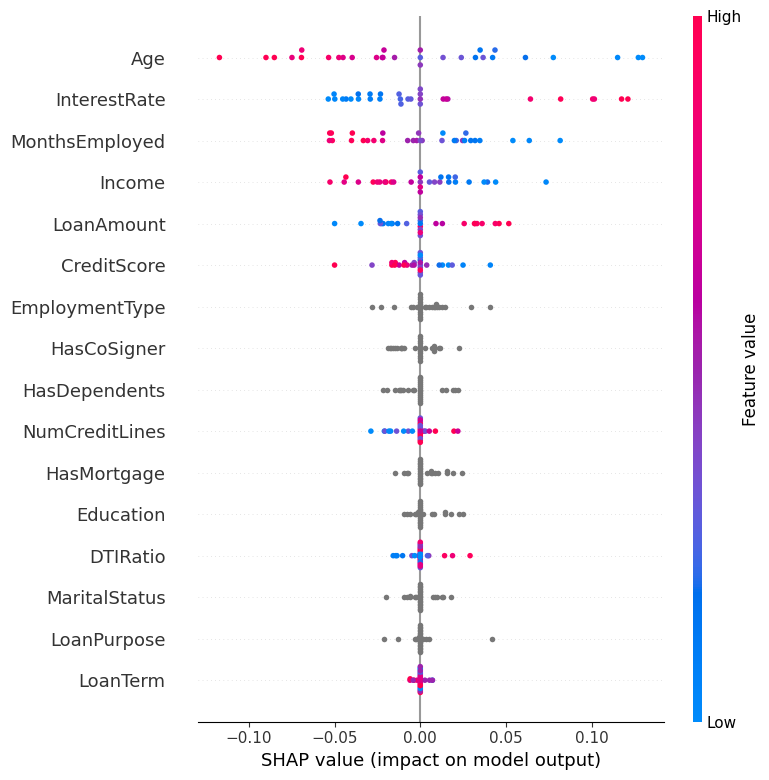

In [16]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_shap,
    show=True
)

plt.tight_layout()
plt.savefig(
    os.path.join(OUT_DIR, "shap_summary_plot.png"),
    bbox_inches="tight",
    dpi=300
)

plt.close()

## 9.2) SHAP Bar Plot

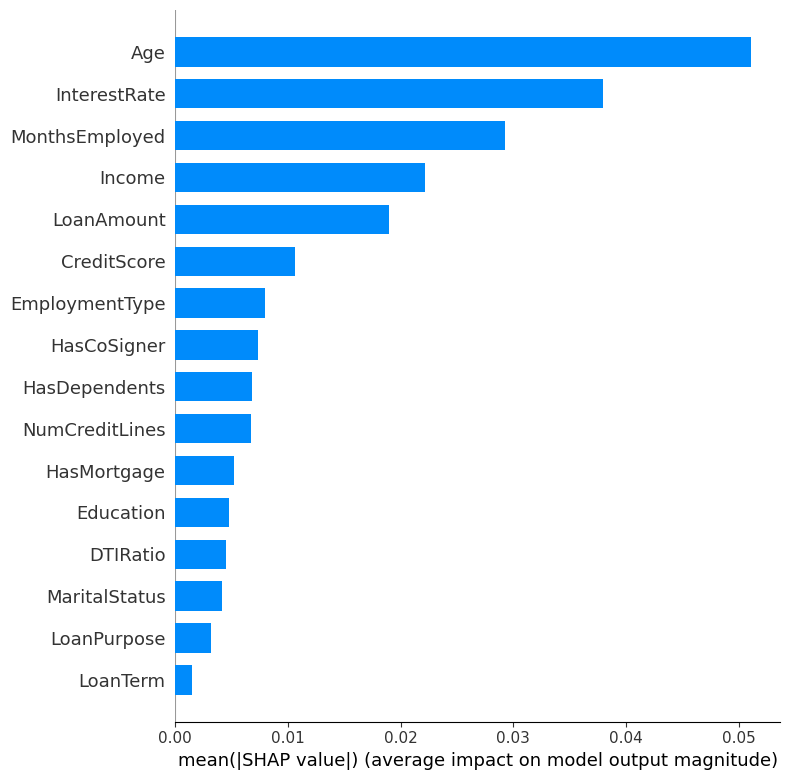

In [17]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    show=True
)

plt.tight_layout()
plt.savefig(
    os.path.join(OUT_DIR, "shap_summary_bar_plot.png"),
    bbox_inches="tight",
    dpi=300
)

plt.close()

# 19) LIME

In [18]:
# prepare data

X_train = train_final[FEATURES].copy()
y_train = train_final[TARGET].astype(int)

X_test = test_final[FEATURES].copy()
y_test = test_final[TARGET].astype(int)

In [19]:
X_train_lime = pd.get_dummies(X_train, drop_first=False)
X_test_lime = pd.get_dummies(X_test, drop_first=False)

X_test_lime = X_test_lime.reindex(
    columns=X_train_lime.columns,
    fill_value=0
)

X_train_lime = X_train_lime.astype(float)
X_test_lime = X_test_lime.astype(float)

lime_explainer = LimeTabularExplainer(
    training_data=X_train_lime.values,
    feature_names=X_train_lime.columns.tolist(),
    class_names=["Non-Default", "Default"],
    mode="classification"
)


def predict_final_pd_from_encoded_h2o(data):

    df_encoded = pd.DataFrame(
        data,
        columns=X_train_lime.columns
    )

    df_original = pd.DataFrame(index=df_encoded.index)

    for col in X_train.columns:

        dummy_cols = [
            c for c in df_encoded.columns
            if c.startswith(f"{col}_")
        ]

        if dummy_cols:
            df_original[col] = (
                df_encoded[dummy_cols]
                .idxmax(axis=1)
                .str[len(col) + 1:]
            )
        else:
            df_original[col] = df_encoded[col]

    df_original = df_original[X_train.columns]

    tmp = df_original.copy()
    tmp[TARGET] = 0

    h2o_frame = make_h2o_frame(tmp, TARGET)

    pd_raw = get_positive_class_proba_h2o(
        leader,
        h2o_frame
    )

    pd_be = inv_logit(logit(pd_raw) + alpha_shift)

    moc_a = pd_be * MOC_A_UPLIFT

    moc_c = np.full_like(
        pd_be,
        np.mean(moc_c_test),
        dtype=float
    )

    return apply_final_pd_adjustments(
        pd_be=pd_be,
        moc_a=moc_a,
        moc_c=moc_c,
        pd_floor=PD_FLOOR
    )


def predict_proba_fn_lime_h2o(data):

    pd_final = predict_final_pd_from_encoded_h2o(data)

    return np.column_stack([
        1 - pd_final,
        pd_final
    ])


instance_idx = 0

lime_exp = lime_explainer.explain_instance(
    data_row=X_test_lime.iloc[instance_idx].values,
    predict_fn=predict_proba_fn_lime_h2o,
    num_features=10
)

lime_exp.show_in_notebook(show_table=True)

/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


In [20]:
lime_exp.save_to_file(
    os.path.join(OUT_DIR, "lime_explanation.html")
)

print("Level 3 explainability outputs saved.")

Level 3 explainability outputs saved.


# 9) Evaluation: Lorenz Curve & Calibration Curve

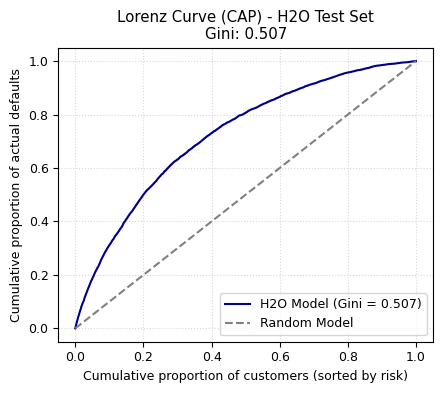

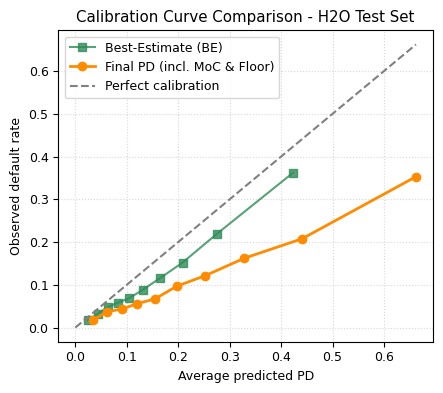

Saved H2O IRBA-compliant plots to: /content/h2o_level1_outputs/thesis_plots


In [21]:
# H2O data preparation for Scikit-Learn & Matplotlib
# (Converts H2O frames to Pandas/NumPy if they are still in H2O format)
try:
    y_test_true = y_test_final.as_data_frame().iloc[:, 0].values if hasattr(y_test_final, "as_data_frame") else np.asarray(y_test_final)
    pd_test_be_arr = pd_test_be.as_data_frame().iloc[:, 0].values if hasattr(pd_test_be, "as_data_frame") else np.asarray(pd_test_be)
    pd_test_final_arr = pd_test_final.as_data_frame().iloc[:, 0].values if hasattr(pd_test_final, "as_data_frame") else np.asarray(pd_test_final)
except Exception:
    # Fallback,if it is NumPy/Pandas-Objekte already
    y_test_true = np.asarray(y_test_final)
    pd_test_be_arr = np.asarray(pd_test_be)
    pd_test_final_arr = np.asarray(pd_test_final)


# IRB Best Practice: Use Unbiased Best-Estimate PDs for Lorenz/Gini
# to prevent artificial Gini deflation caused by regulatory floors.
y_test_proba_lorenz = pd_test_be_arr

plt.rcParams.update({
    "font.size": 9
})

# ============================================================
#  Lorenz curve (CAP / Cumulative Gains) - H2O Test Set
# ============================================================

# Evaluate the discriminatory power of the H2O PD model.
# Customers are sorted from highest predicted risk to lowest.
#
# Interpretation:
# - A curve far above the diagonal indicates strong risk separation.
# - The diagonal represents a random model.
# - The Gini coefficient summarizes discrimination (> 0.50 is strong).

# Create DataFrame and sort observations by predicted PD
# Create DataFrame and sort observations by unbiased predicted PD
df_lorenz = pd.DataFrame({"y_true": y_test_true, "y_proba": y_test_proba_lorenz})
df_lorenz = df_lorenz.sort_values(by="y_proba", ascending=False).reset_index(drop=True)

# Cumulative percentage of customers
cum_population = np.arange(1, len(df_lorenz) + 1) / len(df_lorenz)
# Cumulative percentage of observed defaults
cum_defaults = df_lorenz["y_true"].cumsum() / df_lorenz["y_true"].sum()

# Convert ROC-AUC into Gini coefficient based on BE-PD
roc_auc = roc_auc_score(y_test_true, y_test_proba_lorenz)
gini_score = 2 * roc_auc - 1

plt.figure(figsize=(4.5, 4))
plt.plot(cum_population, cum_defaults, color="darkblue", label=f"H2O Model (Gini = {gini_score:.3f})")
# Random model benchmark
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Model")

plt.xlabel("Cumulative proportion of customers (sorted by risk)")
plt.ylabel("Cumulative proportion of actual defaults")
plt.title(f"Lorenz Curve (CAP) - H2O Test Set\nGini: {gini_score:.3f}")
plt.legend(loc="lower right")
plt.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
lorenz_path = os.path.join(PLOT_DIR, "lorenz_curve_h2o_test.png")
plt.savefig(lorenz_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# ============================================================
# Combined Calibration Curve - H2O Test Set
# ============================================================
# Purpose:
# Compare the calibrated Best-Estimate (BE) PDs against the
# final conservative PDs (including MoCs and regulatory floors).
#
# Interpretation:
# - The BE line reflects the unbiased model fit after the alpha-shift.
# - The Final PD line incorporates mandated regulatory margins.
# - Points below the diagonal indicate compliant, conservative risk overestimation.
# - A score near to 0 is good ( 0 = perfect)

#  Calculation for unbiased Best-Estimate (BE) PDs
prob_true_be, prob_pred_be = calibration_curve(
    y_test_true,
    pd_test_be_arr,
    n_bins=10,
    strategy="quantile"
)

# Calculation for final regulatory PDs
prob_true_final, prob_pred_final = calibration_curve(
    y_test_true,
    pd_test_final_arr,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(4.5, 4))

# Best-Estimate (BE) line (green)
plt.plot(prob_pred_be, prob_true_be, "s-", color="seagreen", alpha=0.8, label="Best-Estimate (BE)")

# final PD line  (orange)
plt.plot(prob_pred_final, prob_true_final, "o-", color="darkorange", lw=2, label="Final PD (incl. MoC & Floor)")

# Draw a perfect calibration line (up to the maximum predicted PD)
max_val = max(max(prob_pred_be), max(prob_pred_final)) if len(prob_pred_final) > 0 else 1.0
plt.plot([0, max_val], [0, max_val], linestyle="--", color="gray", label="Perfect calibration")

plt.xlabel("Average predicted PD")
plt.ylabel("Observed default rate")
plt.title("Calibration Curve Comparison - H2O Test Set")
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
calib_path = os.path.join(PLOT_DIR, "calibration_curve_h2o_test.png")
plt.savefig(calib_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved H2O IRBA-compliant plots to:", PLOT_DIR)

##9.1) Output of Scores

In [22]:
# convert in numpy/pandas
try:
    y_test_true_arr = y_test_final.as_data_frame().iloc[:, 0].values if hasattr(y_test_final, "as_data_frame") else np.asarray(y_test_final)
    pd_test_be_arr = pd_test_be.as_data_frame().iloc[:, 0].values if hasattr(pd_test_be, "as_data_frame") else np.asarray(pd_test_be)
    pd_test_final_arr = pd_test_final.as_data_frame().iloc[:, 0].values if hasattr(pd_test_final, "as_data_frame") else np.asarray(pd_test_final)
except Exception:
    # Fallback
    y_test_true_arr = np.asarray(y_test_final)
    pd_test_be_arr = np.asarray(pd_test_be)
    pd_test_final_arr = np.asarray(pd_test_final)

# calculate Gini-coefficient using the prepared H2O arrays
auc_be = roc_auc_score(y_test_true_arr, pd_test_be_arr)
gini_be = 2 * auc_be - 1

auc_final = roc_auc_score(y_test_true_arr, pd_test_final_arr)
gini_final = 2 * auc_final - 1

# Calculate calibration quality using the Brier Score
# Lower values indicate better calibration and probability accuracy.
brier_be = brier_score_loss(y_test_true_arr, pd_test_be_arr)
brier_final = brier_score_loss(y_test_true_arr, pd_test_final_arr)

# Store all evaluation metrics in a DataFrame
irba_metrics_summary = pd.DataFrame({
    "Model_Stage": ["Best-Estimate (BE)", "Final (incl. MoC & Floor)"],
    "Gini_Coefficient": [gini_be, gini_final],
    "Brier_Score_Calibration": [brier_be, brier_final]
})

# Save as CSV specifically for the H2O model evaluation
irba_metrics_summary.to_csv(os.path.join(OUT_DIR, "irba_performance_metrics_h2o.csv"), index=False)

print("H2O CORE IRBA PERFORMANCE METRICS (TEST SET)")
print(irba_metrics_summary.to_string(index=False))


H2O CORE IRBA PERFORMANCE METRICS (TEST SET)
              Model_Stage  Gini_Coefficient  Brier_Score_Calibration
       Best-Estimate (BE)          0.506542                 0.093463
Final (incl. MoC & Floor)          0.499585                 0.114623
